In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import cross_val_score

from xgboost import XGBClassifier

import optuna

In [11]:
train = pd.read_csv("/Users/kartikeyrana/Downloads/ait-511-course-project-1-obesity-risk/train.csv")
test = pd.read_csv("/Users/kartikeyrana/Downloads/ait-511-course-project-1-obesity-risk/test.csv")

In [12]:
train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,WeightCategory
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [13]:
print('The dimension of the train dataset is:', train.shape)
print('The dimension of the test dataset is:', test.shape)

The dimension of the train dataset is: (15533, 18)
The dimension of the test dataset is: (5225, 17)


In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15533 entries, 0 to 15532
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              15533 non-null  int64  
 1   Gender                          15533 non-null  object 
 2   Age                             15533 non-null  float64
 3   Height                          15533 non-null  float64
 4   Weight                          15533 non-null  float64
 5   family_history_with_overweight  15533 non-null  object 
 6   FAVC                            15533 non-null  object 
 7   FCVC                            15533 non-null  float64
 8   NCP                             15533 non-null  float64
 9   CAEC                            15533 non-null  object 
 10  SMOKE                           15533 non-null  object 
 11  CH2O                            15533 non-null  float64
 12  SCC                             

In [15]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5225 entries, 0 to 5224
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              5225 non-null   int64  
 1   Gender                          5225 non-null   object 
 2   Age                             5225 non-null   float64
 3   Height                          5225 non-null   float64
 4   Weight                          5225 non-null   float64
 5   family_history_with_overweight  5225 non-null   object 
 6   FAVC                            5225 non-null   object 
 7   FCVC                            5225 non-null   float64
 8   NCP                             5225 non-null   float64
 9   CAEC                            5225 non-null   object 
 10  SMOKE                           5225 non-null   object 
 11  CH2O                            5225 non-null   float64
 12  SCC                             52

In [16]:
train.describe()

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,15533.000000,15533.000000,15533.000000,15533.000000,15533.000000,15533.000000,15533.000000,15533.000000,15533.000000
mean,7766.000000,23.816308,1.699918,87.785225,2.442917,2.760425,2.027626,0.976968,0.613813
std,4484.135201,5.663167,0.087670,26.369144,0.530895,0.706463,0.607733,0.836841,0.602223
min,0.000000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,3883.000000,20.000000,1.630927,66.000000,2.000000,3.000000,1.796257,0.007050,0.000000
50%,7766.000000,22.771612,1.700000,84.000000,2.342220,3.000000,2.000000,1.000000,0.566353
75%,11649.000000,26.000000,1.762921,111.600553,3.000000,3.000000,2.531456,1.582675,1.000000
max,15532.000000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


In [17]:
test.describe()

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,5225.000000,5225.000000,5225.000000,5225.000000,5225.000000,5225.00000,5225.000000,5225.000000,5225.000000
mean,18145.000000,23.917600,1.701216,88.192612,2.454802,2.76403,2.034746,0.995953,0.625505
std,1508.471909,5.761355,0.086240,26.410210,0.540020,0.70219,0.610672,0.842551,0.601761
min,15533.000000,14.000000,1.463167,39.101805,1.000000,1.00000,1.000000,0.000000,0.000000
25%,16839.000000,20.000000,1.632983,66.500000,2.000000,3.00000,1.785804,0.015860,0.000000
50%,18145.000000,22.875223,1.700000,85.000000,2.499388,3.00000,2.000000,1.000000,0.582840
75%,19451.000000,26.000000,1.761519,111.720238,3.000000,3.00000,2.559750,1.624981,1.000000
max,20757.000000,55.246250,1.947406,165.057269,3.000000,4.00000,3.000000,3.000000,2.000000


In [18]:
full_form = dict({'FAVC' : "Frequent consumption of high caloric food",
                  'FCVC' : "Frequency of consumption of vegetables",
                  'NCP' :"Number of main meal",
                  'CAEC': "Consumption of food between meals",
                  'CH2O': "Consumption of water daily",
                  'SCC':  "Calories consumption monitoring",
                  'FAF': "Physical activity frequency",
                  'TUE': "Time using technology devices",
                  'CALC': "Consumption of alcohol" ,
                  'MTRANS' : "Transportation used"})

In [19]:
for col in train.columns:
    if train[col].dtype == 'object' :
        display(train[col].value_counts())
        print('--------------------------------------')

Gender
Male      7783
Female    7750
Name: count, dtype: int64

--------------------------------------


family_history_with_overweight
yes    12696
no      2837
Name: count, dtype: int64

--------------------------------------


FAVC
yes    14184
no      1349
Name: count, dtype: int64

...

--------------------------------------


MTRANS
Public_Transportation    12470
Automobile                2669
Walking                    340
Motorbike                   30
Bike                        24
Name: count, dtype: int64

--------------------------------------


WeightCategory
Obesity_Type_III       2983
Obesity_Type_II        2403
Normal_Weight          2345
Obesity_Type_I         2207
Overweight_Level_II    1881
Insufficient_Weight    1870
Overweight_Level_I     1844
Name: count, dtype: int64

--------------------------------------


#### 2.1 Binary Freatures 

**Gender**: already balanced, keeping as it is.

**family_history_with_overweight**: The 'no' class (2837) is substantial. Keep as is.

**FAVC**: The 'no' class (1349) is small but still significant. Keep as is.

**SCC**: The 'yes' class (514) is small, but monitoring calories is likely a very strong signal related to weight. Keep as is for now, but monitor its feature importance later.

---


#### 2.2 CAEC(Consumption of food between meals)

In [20]:
filtered_df = train[train['CAEC'].isin(['no', 'Sometimes', 'Always', 'Frequently'])]
combined_table = pd.crosstab(filtered_df['WeightCategory'], filtered_df['CAEC'])

display(combined_table)

CAEC,Always,Frequently,Sometimes,no
WeightCategory,,,,
Insufficient_Weight,22,897,946,5
Normal_Weight,205,542,1573,25
Obesity_Type_I,50,43,2109,5
Obesity_Type_II,7,8,2386,2
Obesity_Type_III,1,1,2981,0
Overweight_Level_I,40,209,1433,162
Overweight_Level_II,21,158,1698,4


**CAEC provides exteremly strong and highly predictive features so this will be kept as it is**

#### 2.3 family_history_with_overweight

In [21]:
filtered_df = train[train['family_history_with_overweight'].isin(['yes', 'no'])]
combined_table = pd.crosstab(filtered_df['WeightCategory'], filtered_df['family_history_with_overweight'])

print(combined_table)

family_history_with_overweight    no   yes
WeightCategory                            
Insufficient_Weight             1081   789
Normal_Weight                    992  1353
Obesity_Type_I                    34  2173
Obesity_Type_II                    5  2398
Obesity_Type_III                   1  2982
Overweight_Level_I               589  1255
Overweight_Level_II              135  1746


**family_history_with_overweight feature provides a good distinction between obese and non-obese categories so it will be kept as it is**

#### 2.4 Smoke Feature

In [22]:
filtered_df = train[train['SMOKE'].isin(['yes', 'no'])]
combined_table = pd.crosstab(filtered_df['WeightCategory'], filtered_df['SMOKE'])

print(combined_table)

SMOKE                  no  yes
WeightCategory                
Insufficient_Weight  1865    5
Normal_Weight        2318   27
Obesity_Type_I       2186   21
Obesity_Type_II      2319   84
Obesity_Type_III     2981    2
Overweight_Level_I   1825   19
Overweight_Level_II  1862   19


**cant drop the SMOKE = 'yes' data points because if the person smokes then its highly suggestive that they may fall into 'Obesity_Type_II' WeightCategory**

#### 2.5 FAVC Frequent consumption of high caloric food"

In [23]:
filtered_df = train[train['FAVC'].isin(['yes', 'no'])]
combined_table = pd.crosstab(filtered_df['WeightCategory'], filtered_df['FAVC'])

print(combined_table)

FAVC                  no   yes
WeightCategory                
Insufficient_Weight  274  1596
Normal_Weight        371  1974
Obesity_Type_I        72  2135
Obesity_Type_II       43  2360
Obesity_Type_III       1  2982
Overweight_Level_I   171  1673
Overweight_Level_II  417  1464


#### 2.6 SCC Calories consumption monitoring

In [24]:
filtered_df = train[train['SCC'].isin(['yes', 'no'])]
combined_table = pd.crosstab(filtered_df['WeightCategory'], filtered_df['SCC'])

print(combined_table)

SCC                    no  yes
WeightCategory                
Insufficient_Weight  1701  169
Normal_Weight        2217  128
Obesity_Type_I       2194   13
Obesity_Type_II      2399    4
Obesity_Type_III     2983    0
Overweight_Level_I   1661  183
Overweight_Level_II  1864   17


**SCC = yes is a Strong Negative Predictor for Obesity**

#### 2.7 CALC Consumption of alcohol

In [25]:
filtered_df = train[train['CALC'].isin(['Sometimes', 'no', 'Frequently'])]
combined_table = pd.crosstab(filtered_df['WeightCategory'], filtered_df['CALC'])

print(combined_table)

CALC                 Frequently  Sometimes    no
WeightCategory                                  
Insufficient_Weight          10       1215   645
Normal_Weight                56       1483   806
Obesity_Type_I               57       1103  1047
Obesity_Type_II               9       2071   323
Obesity_Type_III              0       2983     0
Overweight_Level_I           97       1477   270
Overweight_Level_II         178        953   750


#### 2.8 MTRANS Mode of Transportation

In [26]:
filtered_df = train[train['MTRANS'].isin(['Public_Transportation', 'Automobile', 'Walking', 'Motorbike','Bike'])]
combined_table = pd.crosstab(filtered_df['WeightCategory'], filtered_df['MTRANS'])

print(combined_table)

MTRANS               Automobile  Bike  Motorbike  Public_Transportation  \
WeightCategory                                                            
Insufficient_Weight         212     1          3                   1602   
Normal_Weight               254    11         15                   1938   
Obesity_Type_I              570     1          2                   1614   
Obesity_Type_II             685     1          2                   1711   
Obesity_Type_III              0     0          0                   2983   
Overweight_Level_I          373     7          5                   1383   
Overweight_Level_II         575     3          3                   1239   

MTRANS               Walking  
WeightCategory                
Insufficient_Weight       52  
Normal_Weight            127  
Obesity_Type_I            20  
Obesity_Type_II            4  
Obesity_Type_III           0  
Overweight_Level_I        76  
Overweight_Level_II       61  


**we shall merge the rare categories in this feature which can help improve the meaning of data set**

In [27]:
merge_map = {
    'Walking': 'Active_Transport',
    'Bike': 'Active_Transport',
    'Automobile': 'Private_Transport',
    'Motorbike': 'Private_Transport',
}

train['MTRANS'] = train['MTRANS'].replace(merge_map)
test['MTRANS'] = test['MTRANS'].replace(merge_map)

filtered_df = train[train['MTRANS'].isin(['Active_Transport', 'Private_Transport', 'Public_Transportation'])]
combined_table = pd.crosstab(filtered_df['WeightCategory'], filtered_df['MTRANS'])

print(combined_table)

MTRANS               Active_Transport  Private_Transport  \
WeightCategory                                             
Insufficient_Weight                53                215   
Normal_Weight                     138                269   
Obesity_Type_I                     21                572   
Obesity_Type_II                     5                687   
Obesity_Type_III                    0                  0   
Overweight_Level_I                 83                378   
Overweight_Level_II                64                578   

MTRANS               Public_Transportation  
WeightCategory                              
Insufficient_Weight                   1602  
Normal_Weight                         1938  
Obesity_Type_I                        1614  
Obesity_Type_II                       1711  
Obesity_Type_III                      2983  
Overweight_Level_I                    1383  
Overweight_Level_II                   1239  


## 3. Creating Interacting features

In [28]:
from sklearn.preprocessing import LabelEncoder
numerical_train = train.select_dtypes(include=['number'])
numerical_train = numerical_train.drop('id', axis = 1)

corr_mat = numerical_train.corr()
corr_mat

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000000,-0.014824,0.280320,0.030279,-0.051373,-0.021965,-0.194451,-0.294959
Height,-0.014824,1.000000,0.420702,-0.067065,0.196410,0.186031,0.298812,0.080091
Weight,0.280320,0.420702,1.000000,0.248445,0.096474,0.316199,-0.075771,-0.082261
FCVC,0.030279,-0.067065,0.248445,1.000000,0.107310,0.103753,-0.081098,-0.150290
NCP,-0.051373,0.196410,0.096474,0.107310,1.000000,0.073561,0.105726,0.074077
CH2O,-0.021965,0.186031,0.316199,0.103753,0.073561,1.000000,0.081823,-0.015740
FAF,-0.194451,0.298812,-0.075771,-0.081098,0.105726,0.081823,1.000000,0.014926
TUE,-0.294959,0.080091,-0.082261,-0.150290,0.074077,-0.015740,0.014926,1.000000


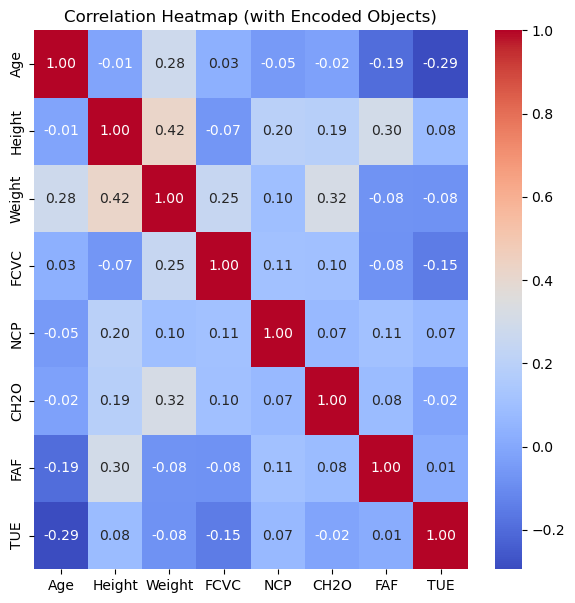

In [35]:
plt.figure(figsize=(7, 7))
sns.heatmap(
    corr_mat, 
    annot=True,      
    fmt='.2f',       
    cmap='coolwarm'  
)
plt.title("Correlation Heatmap (with Encoded Objects)")
plt.show()

In [36]:
train['BMI'] = train['Weight'] / (train['Height'] ** 2)
test['BMI'] = test['Weight'] / (test['Height'] ** 2)

In [37]:
train['BMI_Squared'] = train['BMI']**2
test['BMI_Squared'] = test['BMI']**2

In [38]:
print(f"Min Age: {train['Age'].min()}")
print(f"Max Age: {train['Age'].max()}")

Min Age: 14.0
Max Age: 61.0


In [39]:
min_age = 10  
max_age = 65
train_ag = train.copy()
bins = list(range(min_age, max_age + 5, 5))
# Creates labels like '10-14', '15-19', '20-24', ...
labels = [f'{i}-{i+4}' for i in bins[:-1]]

train_ag['Age_Group'] = pd.cut(train_ag['Age'], bins=bins, labels=labels, right=False)

In [41]:
age_distribution_counts = pd.crosstab(train_ag['Age_Group'], train_ag['WeightCategory'])

print("Distribution of WeightCategory by Age Group (Counts):")
display(age_distribution_counts)

Distribution of WeightCategory by Age Group (Counts):


WeightCategory,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Age_Group,,,,,,,
10-14,0,3,0,0,0,0,0
15-19,1334,934,443,6,256,502,386
20-24,514,1179,1145,727,847,947,744
25-29,13,159,178,845,1880,143,201
30-34,4,48,65,693,0,131,387
35-39,4,16,240,90,0,91,88
40-44,1,2,128,41,0,18,27
45-49,0,3,5,1,0,2,14
50-54,0,1,1,0,0,1,2


In [42]:
bins = [0, 19, 30, 50, np.inf]

labels = ['Adolescent', 'Young Adult', 'Adult', 'Senior']
train['Age_Category'] = pd.cut(train['Age'], bins=bins, labels=labels, right=True)
test['Age_Category'] = pd.cut(test['Age'], bins=bins, labels=labels, right=True)

print(train[['Age', 'Age_Category']].head())

print("\nValue counts:")
print(train['Age_Category'].value_counts())

         Age Age_Category
0  24.443011  Young Adult
1  18.000000   Adolescent
2  18.000000   Adolescent
3  20.952737  Young Adult
4  31.641081        Adult

Value counts:
Age_Category
Young Adult    10096
Adolescent      3339
Adult           2052
Senior            46
Name: count, dtype: int64


In [43]:
train['WeightxHeight'] = train['Height']*train['Weight']
test['WeightxHeight'] = test['Height']*test['Weight']
train['WeightxCH2O'] = train['CH2O']*train['Weight']
test['WeightxCH2O'] = test['CH2O']*test['Weight']

In [44]:

train['Healthy_Habit_Score'] = (train['FCVC'] >= 2).astype(int) + \
                       (train['CH2O'] >= 1.5).astype(int) + \
                       ((train['FAF'] >= 1).astype(int) * 3) + \
                       (train['NCP'] <= 3).astype(int)

test['Healthy_Habit_Score'] = (test['FCVC'] >= 2).astype(int) + \
                       (test['CH2O'] >= 1.5).astype(int) + \
                       ((test['FAF'] >= 1).astype(int) * 3) + \
                       (test['NCP'] <= 3).astype(int)

train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,...,TUE,CALC,MTRANS,WeightCategory,BMI,BMI_Squared,Age_Category,WeightxHeight,WeightxCH2O,Healthy_Habit_Score
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,...,0.976473,Sometimes,Public_Transportation,Overweight_Level_II,28.259565,798.603001,Young Adult,138.838752,225.700869,3
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,...,1.000000,no,Private_Transport,Normal_Weight,23.422091,548.594334,Adolescent,88.920000,114.000000,6
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,...,1.673584,no,Public_Transportation,Insufficient_Weight,17.126706,293.324052,Adolescent,85.856681,95.835553,2
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,...,0.780199,Sometimes,Public_Transportation,Obesity_Type_III,44.855798,2012.042650,Young Adult,224.575826,219.762108,6
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,...,0.931721,Sometimes,Public_Transportation,Overweight_Level_II,25.599151,655.316531,Adult,179.546924,185.705892,6


In [45]:
train['Unhealthy_Habit_Score'] = (train['FAVC'] == 'yes').astype(int) + \
                       (train['SMOKE'] == 'yes').astype(int) + \
                       ((train['CALC'] != 'no').astype(int) * 3) + \
                       (train['CAEC'] != 'no').astype(int) + \
                       (train['TUE'] >= 2).astype(int)

test['Unhealthy_Habit_Score'] = (test['FAVC'] == 'yes').astype(int) + \
                       (test['SMOKE'] == 'yes').astype(int) + \
                       ((test['CALC'] != 'no').astype(int) * 3) + \
                       (test['CAEC'] != 'no').astype(int) + \
                       (test['TUE'] >= 2).astype(int)

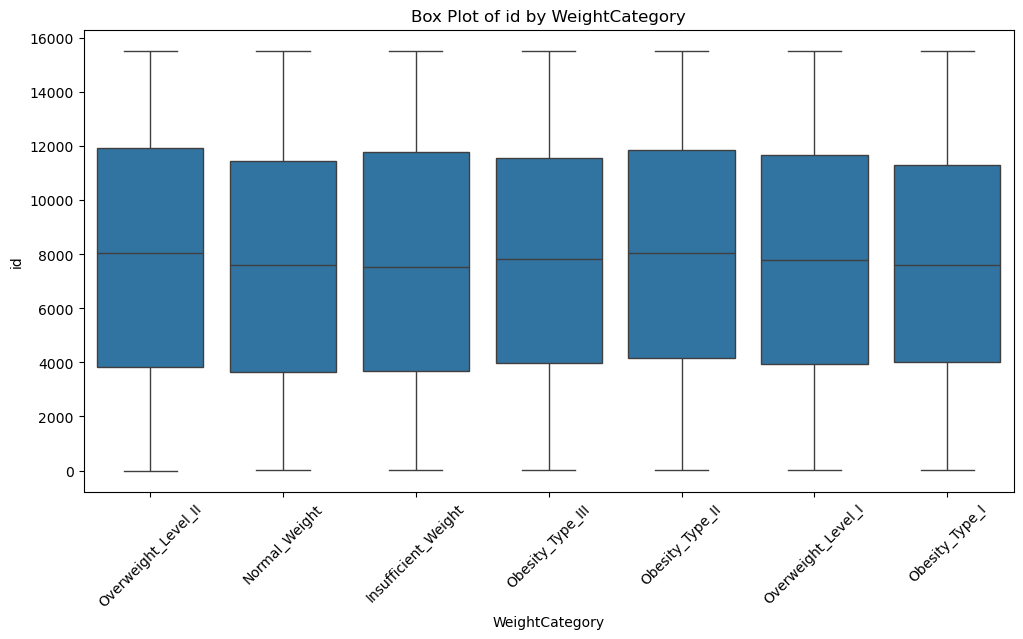

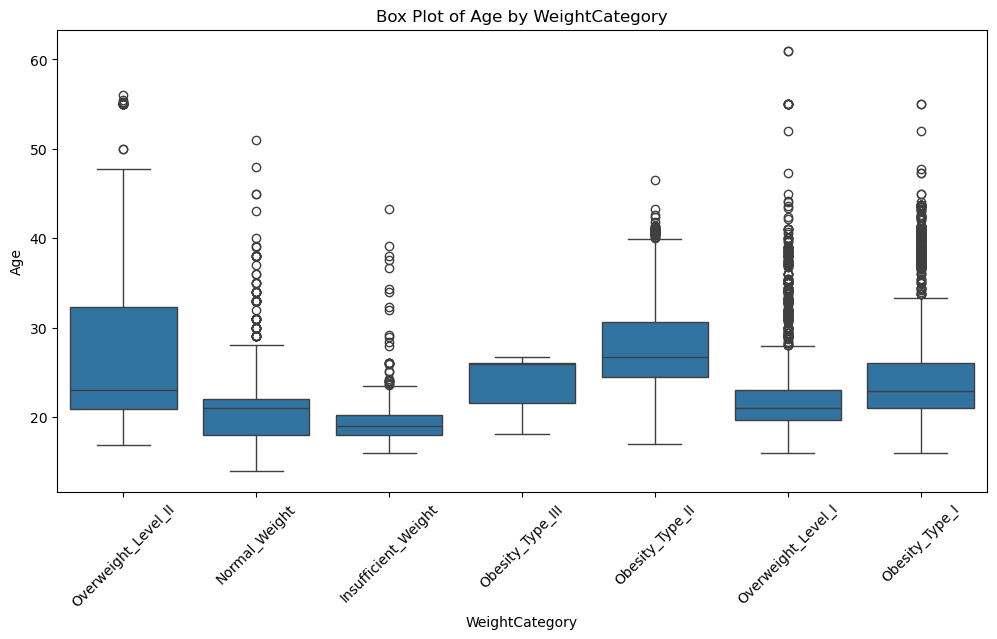

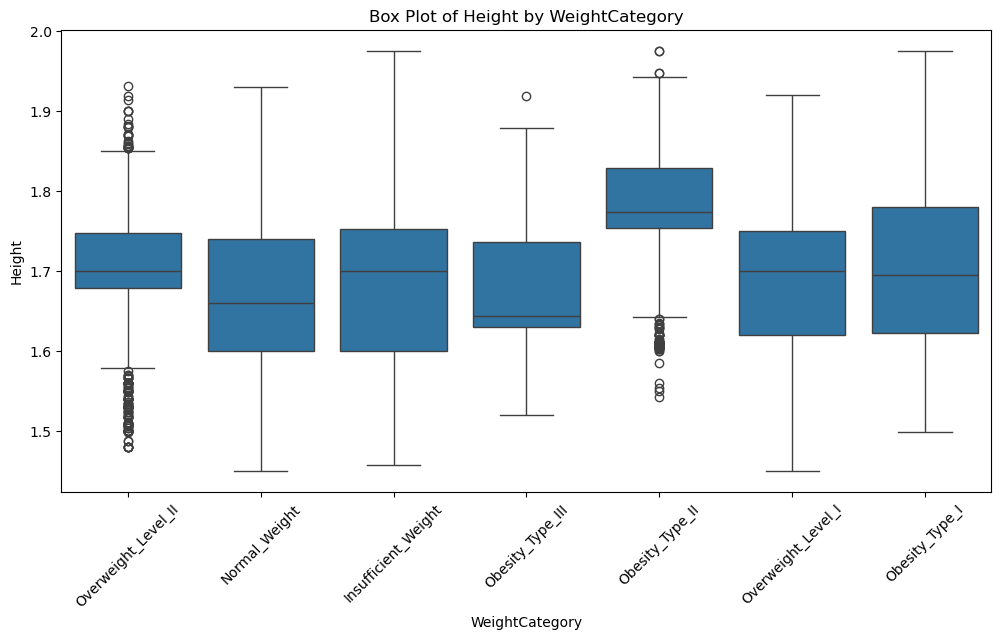

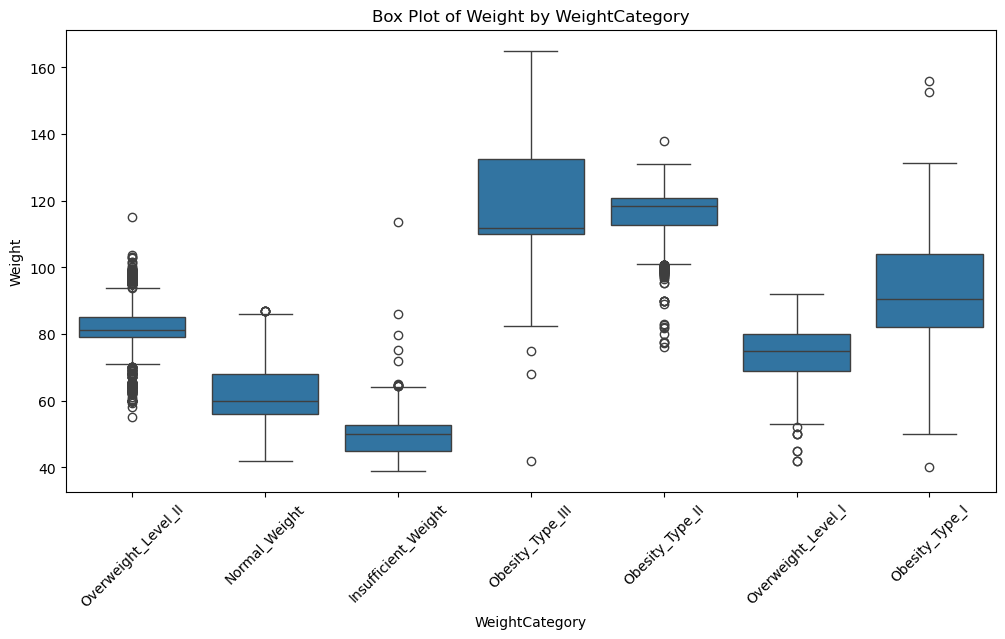

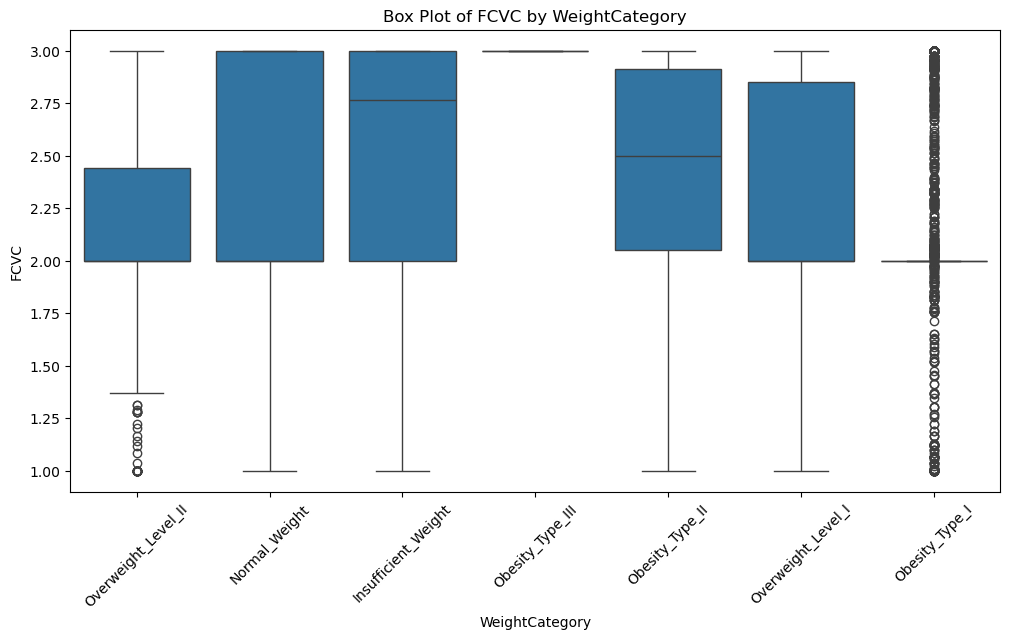

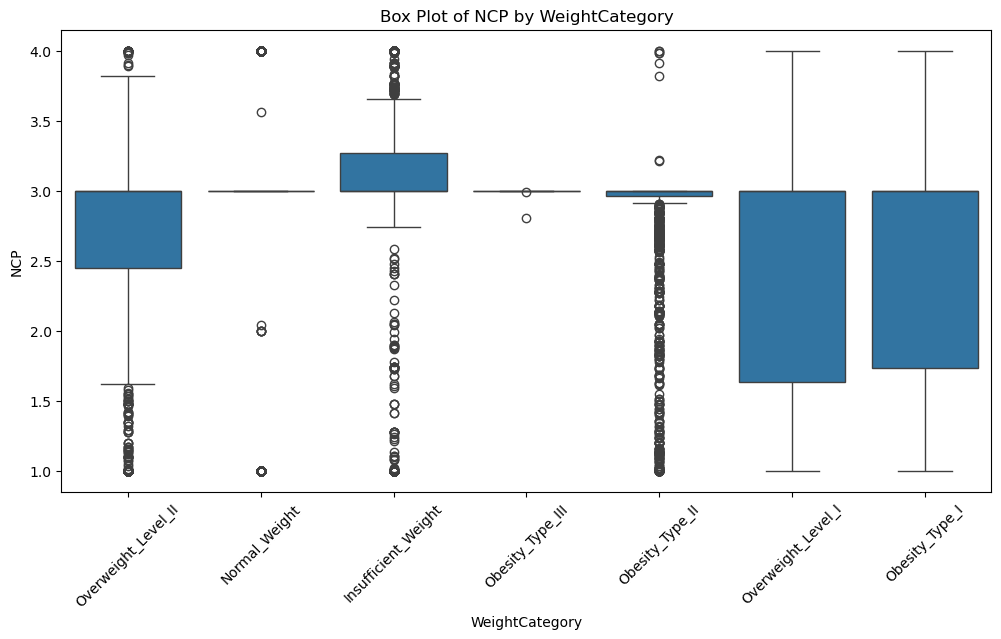

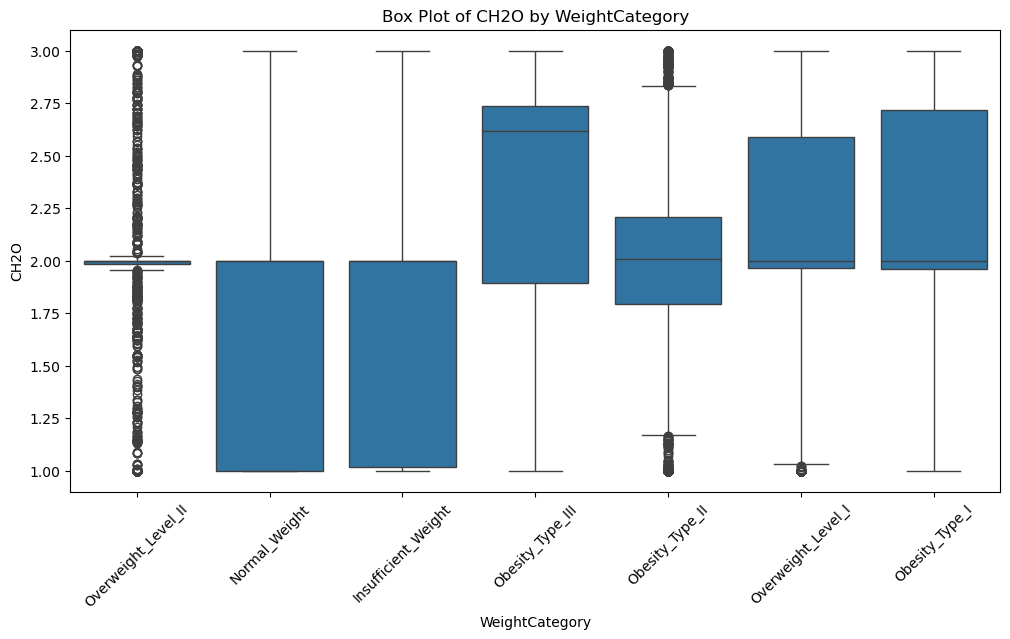

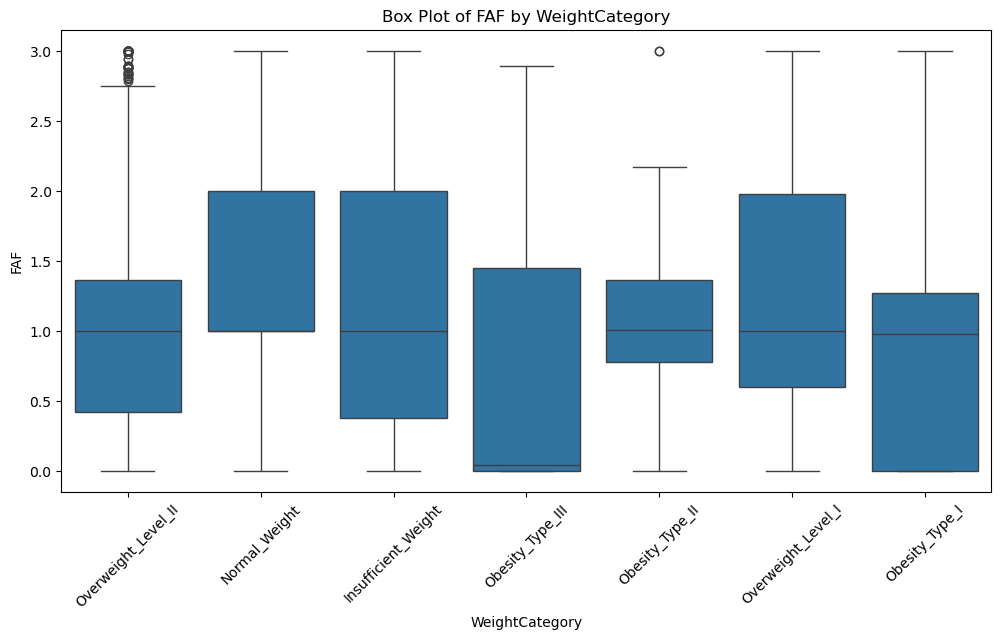

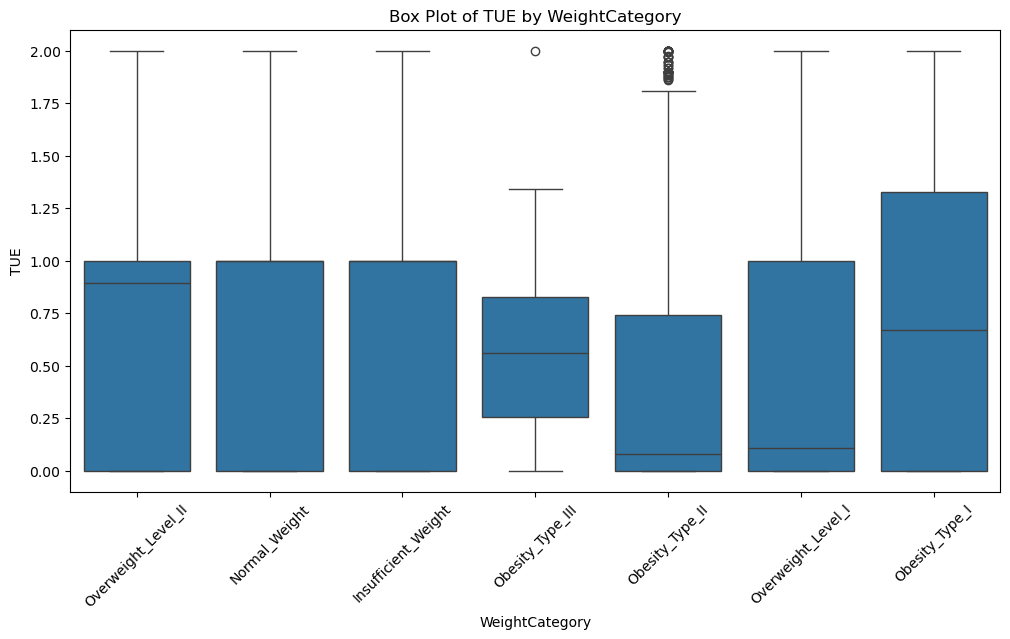

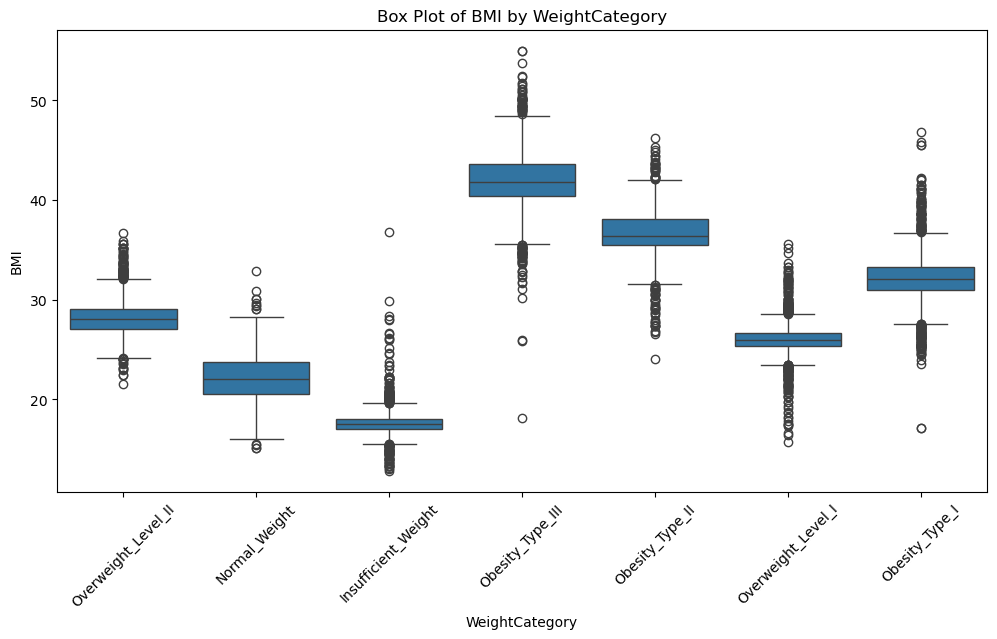

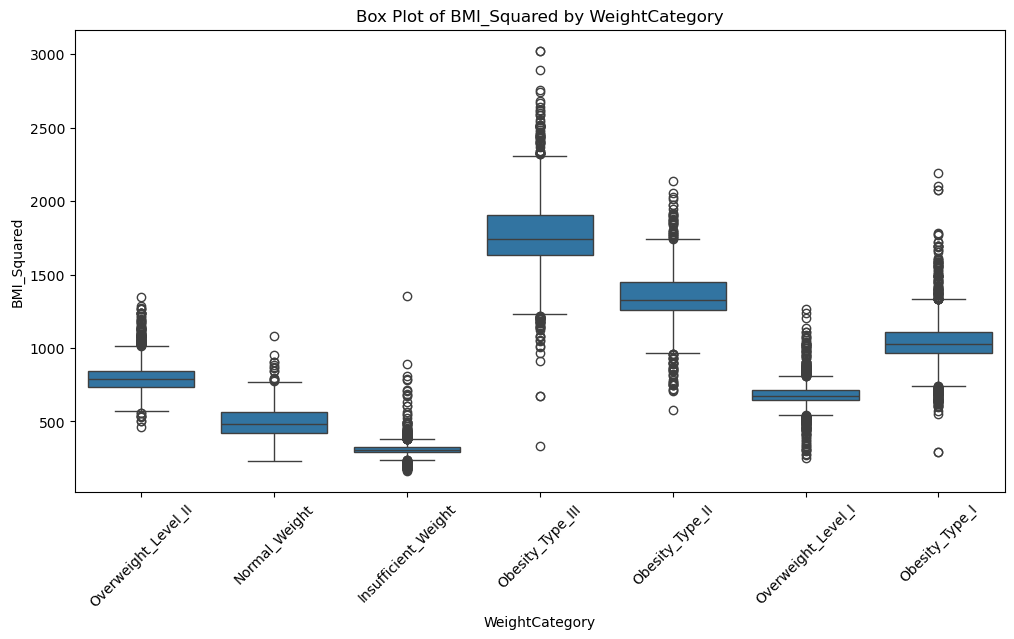

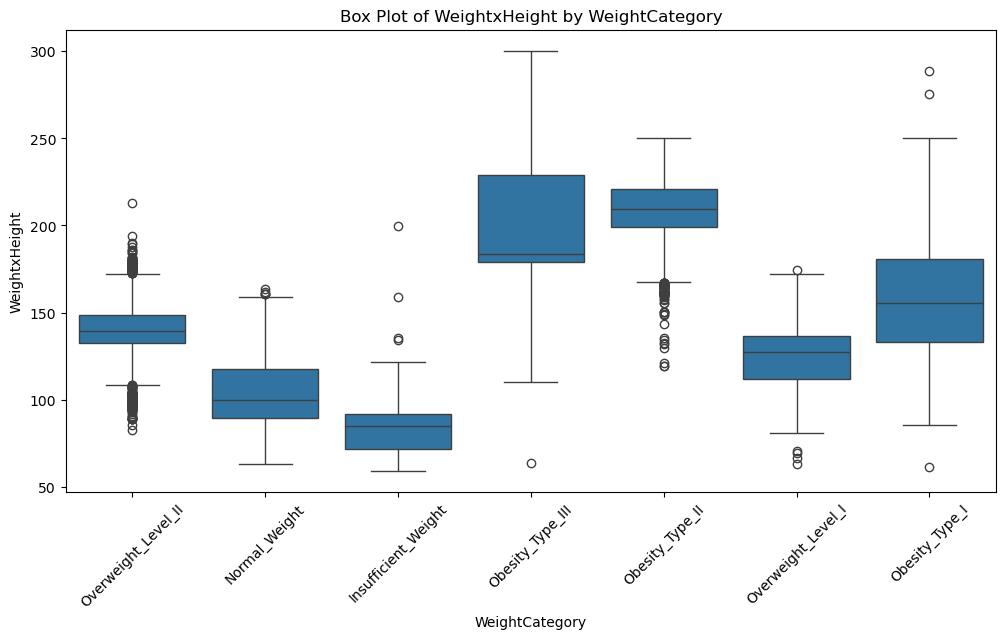

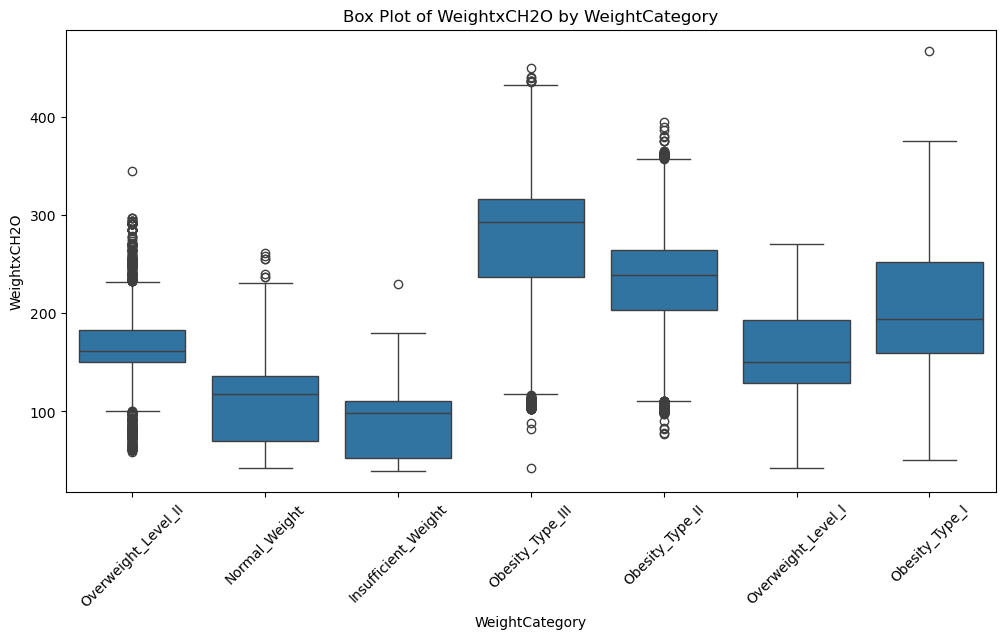

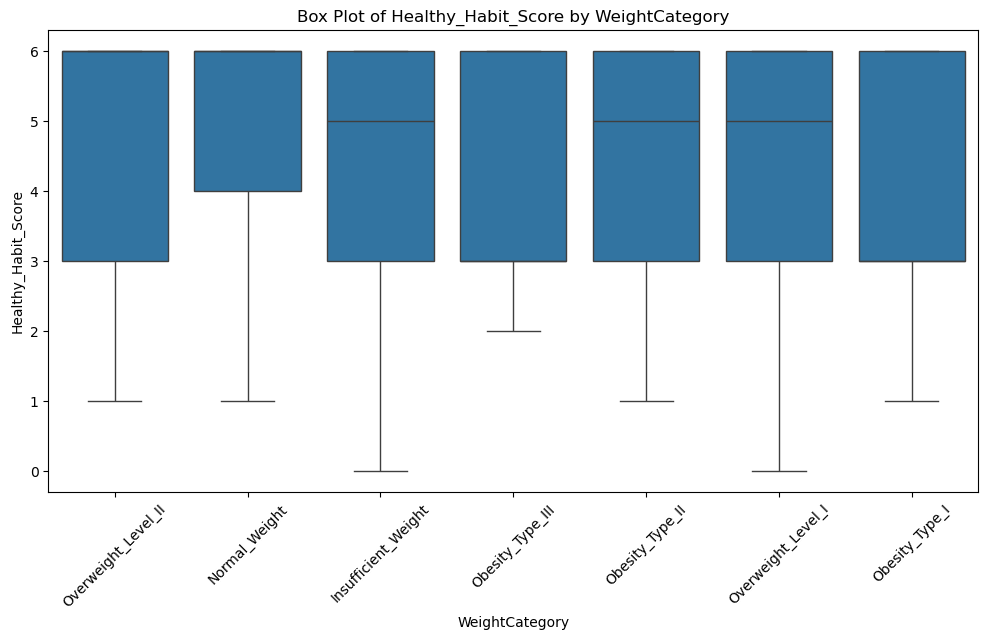

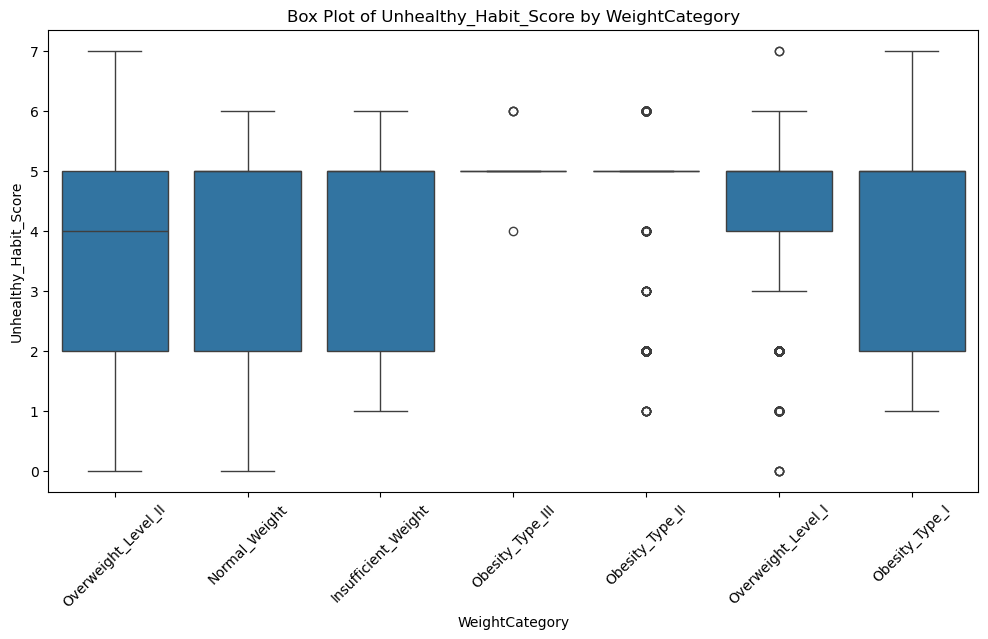

In [46]:
numerical_cols = train.select_dtypes(include=['number']).columns
categorical_col = 'WeightCategory' 

for num_col in numerical_cols:
    plt.figure(figsize=(12, 6)) # Make the plot wide

    sns.boxplot(
        x=categorical_col, 
        y=num_col, 
        data=train
    )
    
    plt.title(f'Box Plot of {num_col} by {categorical_col}')
    plt.xticks(rotation=45) 
    plt.show()

/var/folders/_l/w6nqx76d2nvcmhtjyjm6c_600000gn/T/ipykernel_31630/470659245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train['WeightCategory'], order=train['WeightCategory'].value_counts().index, palette='viridis')


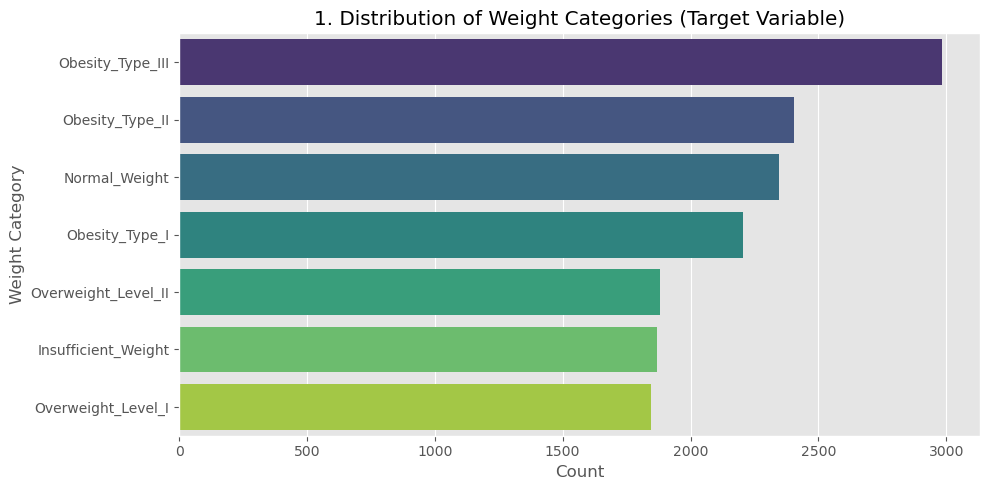

In [49]:
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
sns.countplot(y=train['WeightCategory'], order=train['WeightCategory'].value_counts().index, palette='viridis')
plt.title('1. Distribution of Weight Categories (Target Variable)')
plt.xlabel('Count')
plt.ylabel('Weight Category')
plt.tight_layout()
plt.show() 

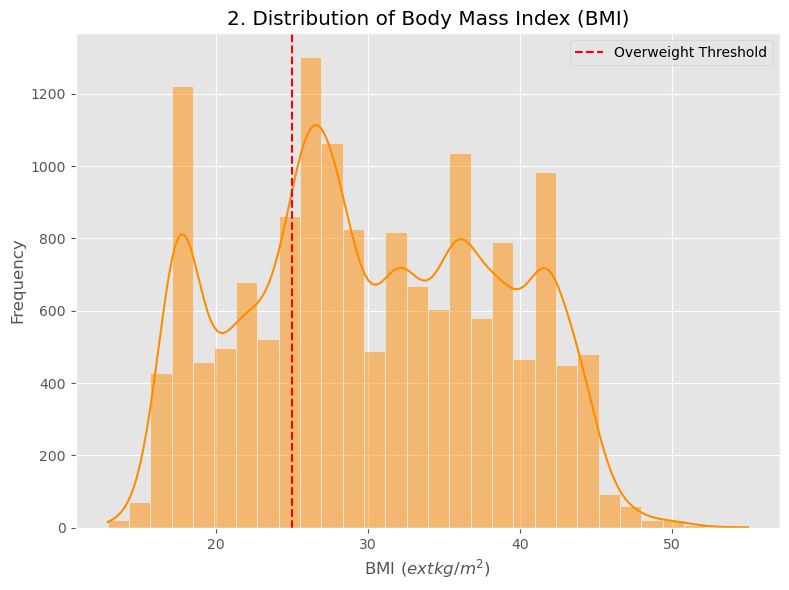

In [51]:
plt.figure(figsize=(8, 6))
sns.histplot(train['BMI'], kde=True, bins=30, color='darkorange')
plt.title('2. Distribution of Body Mass Index (BMI)')
plt.xlabel('BMI ($\text{kg/m}^2$)')
plt.ylabel('Frequency')
plt.axvline(25, color='red', linestyle='--', label='Overweight Threshold')
plt.legend()
plt.tight_layout()
plt.show()

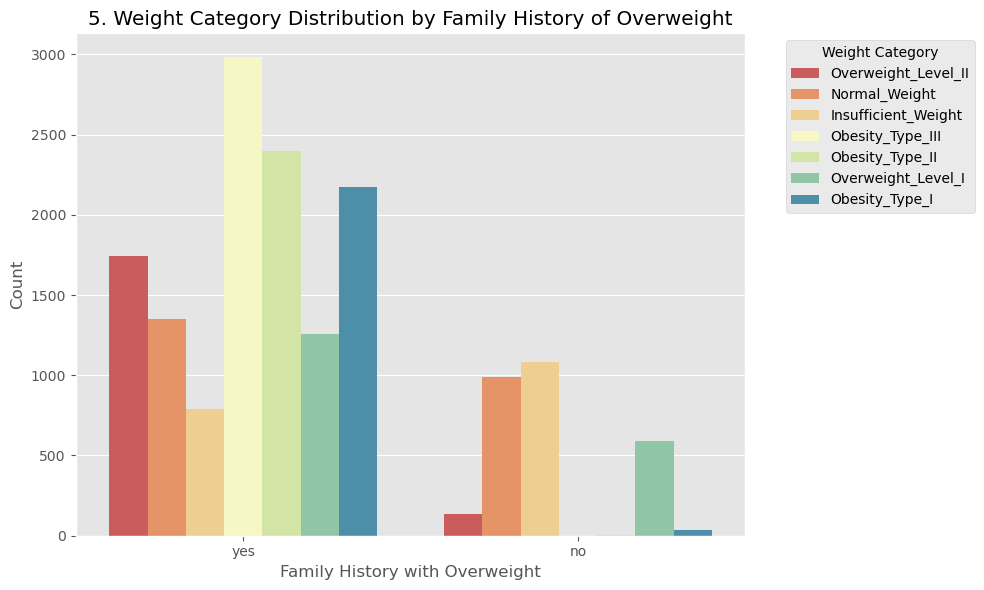

In [58]:
plt.figure(figsize=(10, 6))
sns.countplot(x='family_history_with_overweight', hue='WeightCategory', data=train, palette='Spectral')
plt.title('5. Weight Category Distribution by Family History of Overweight')
plt.xlabel('Family History with Overweight')
plt.ylabel('Count')
plt.legend(title='Weight Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [59]:
numerical_df = train[['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']]
correlation_matrix = numerical_df.corr()

In [4]:
preprocess = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include=object)),
    ("scale", StandardScaler(), make_column_selector(dtype_include=np.number)),
])

X_train, y_train = train.drop("WeightCategory", axis=1), train["WeightCategory"]
preprocess.fit(pd.concat([X_train, test]))
X_train = preprocess.transform(X_train)
X_test_final = preprocess.transform(test)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

## XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score

def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 6, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.08, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 600, 800),
        'subsample': trial.suggest_float('subsample', 0.7, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.30, 0.5),
        'min_child_weight': trial.suggest_int('min_child_weight', 4, 6),
        'gamma': trial.suggest_float('gamma', 0, 2),
    }
    
    model = xgb.XGBClassifier(**param)
    score = cross_val_score(model, X_train, y_train, cv=3).mean()   # calculating score using cross-validation
    return score

    # Best parameters: {'max_depth': 9, 'learning_rate': 0.07538974862984305, 'n_estimators': 782, 'subsample': 0.7080521281561398, 
    # 'colsample_bytree': 0.5445643679776032, 'min_child_weight': 5, 'gamma': 1.1792541260799112}

In [ ]:
import optuna

study = optuna.create_study(study_name="example_xgboost_study", direction='maximize') 
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=-1)   

best_params = study.best_params
print(f"\nBest parameters: {best_params}")

In [ ]:
from sklearn.metrics import accuracy_score, classification_report


best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
cr = classification_report(y_test, y_pred)
print(f"\nReport:\n{cr}")

## AdaBoost

In [9]:
import optuna
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import cross_val_score, KFold

X, y = X_train, y_train

# Trial 44 finished with value: 0.8930381873081119 and parameters: {'estimator_max_depth': 7, 
# 'estimator_min_samples_split': 19, 'estimator_min_samples_leaf': 18, 'estimator_criterion': 'gini', 'n_estimators': 258, 
# 'learning_rate': 0.03450019178398049, 'algorithm': 'SAMME'}. Best is trial 44 with value: 0.8930381873081119.

def objective_ab(trial):    
    estimator_max_depth = trial.suggest_int('estimator_max_depth', 5, 10)
    estimator_min_samples_split = trial.suggest_int('estimator_min_samples_split', 10, 30)
    estimator_min_samples_leaf = trial.suggest_int('estimator_min_samples_leaf', 15, 30)
    estimator_criterion = trial.suggest_categorical('estimator_criterion', ['gini', 'entropy'])

    
    base_estimator = DecisionTreeClassifier(
        max_depth=estimator_max_depth,
        min_samples_split=estimator_min_samples_split,
        min_samples_leaf=estimator_min_samples_leaf,
        criterion=estimator_criterion,
        random_state=42
    )

    
    n_estimators = trial.suggest_int('n_estimators', 100, 600)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.09, log=True)
    algorithm = trial.suggest_categorical('algorithm', ['SAMME'])


    model = AdaBoostClassifier(
        estimator=base_estimator, 
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        algorithm=algorithm,
        random_state=42
    )
    
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')

study.optimize(objective_ab, n_trials=200, show_progress_bar=True, n_jobs=-1)   

print(f"Best trial accuracy: {study.best_value:.4f}")
print("Best hyperparameters found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

print("\nClassification Report:")
print(classification_report(y_test, test_predictions))

[I 2025-10-26 22:16:24,591] A new study created in memory with name: no-name-f3ef1879-e326-48c0-935a-a07f59883d95


  0%|          | 0/200 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorith

[I 2025-10-26 22:16:36,364] Trial 5 finished with value: 0.8833811626195732 and parameters: {'estimator_max_depth': 5, 'estimator_min_samples_split': 22, 'estimator_min_samples_leaf': 25, 'estimator_criterion': 'gini', 'n_estimators': 171, 'learning_rate': 0.01989140954257711, 'algorithm': 'SAMME'}. Best is trial 5 with value: 0.8833811626195732.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1077e9940>>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
  File "/opt/anaconda3/lib/python3.13/threading.py", line 1479, in enumerate
    def enumerate():
KeyboardInterrupt: 


KeyboardInterrupt: 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorith

In [ ]:
y_pred_best = best_model.predict(np.array(X_test_final))
y_pred_best = label_encoder.inverse_transform(y_pred_best)

y_pred_best.shape

In [ ]:
submission = pd.DataFrame({"id": test['id'], "WeightCategory": y_pred_best})
submission.to_csv('/Users/kartikeyrana/Desktop/Course Work/ML/submission_2_testing.csv', index=False)

## Gradient Boosting


In [5]:
import optuna
import sklearn.datasets
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = X_train, y_train

def objective(trial):

    loss_param = trial.suggest_categorical('loss', ['log_loss'])

    criterion_param = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
    n_estimators = trial.suggest_int('n_estimators', 100, 1000, step=100)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 8)
    subsample = trial.suggest_float('subsample', 0.7, 1.0)

    model = GradientBoostingClassifier(
        loss=loss_param,
        criterion=criterion_param,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return accuracy

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=100, n_jobs= -1, show_progress_bar=True) # Run 50 different trials


print(f"Number of finished trials: {len(study.trials)}")
print("Best trial:")
trial = study.best_trial

print(f"  Value (Accuracy): {trial.value:.4f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print("\nClassification Report:")
print(classification_report(y_test, test_predictions))

[I 2025-10-26 16:50:33,991] A new study created in memory with name: no-name-2a9856f8-d41e-4e85-b043-3bf7ee14bf71


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-10-26 16:51:16,808] Trial 4 finished with value: 0.9004291845493563 and parameters: {'loss': 'log_loss', 'criterion': 'friedman_mse', 'n_estimators': 100, 'learning_rate': 0.22989118503305334, 'max_depth': 8, 'subsample': 0.8261654037686976}. Best is trial 4 with value: 0.9004291845493563.
[I 2025-10-26 16:51:17,142] Trial 8 finished with value: 0.8965665236051502 and parameters: {'loss': 'log_loss', 'criterion': 'squared_error', 'n_estimators': 300, 'learning_rate': 0.11741343349357573, 'max_depth': 3, 'subsample': 0.9491037237141801}. Best is trial 4 with value: 0.9004291845493563.
[I 2025-10-26 16:51:33,359] Trial 1 finished with value: 0.9015021459227468 and parameters: {'loss': 'log_loss', 'criterion': 'friedman_mse', 'n_estimators': 200, 'learning_rate': 0.06684965949836362, 'max_depth': 6, 'subsample': 0.9130416920826397}. Best is trial 1 with value: 0.9015021459227468.
[I 2025-10-26 16:51:38,410] Trial 0 finished with value: 0.8965665236051502 and parameters: {'loss': '

In [6]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

best_params = study.best_params

final_model = GradientBoostingClassifier(
    random_state=42, 
    **best_params  
)


final_model.fit(X_train, y_train)
test_predictions = final_model.predict(X_test)

if 'y_test' in locals():
    accuracy = accuracy_score(y_test, test_predictions)
    print(f"\nTest Set Accuracy: {accuracy:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, test_predictions))

Training the final optimal model on all training data...
Training complete.

First 10 predictions on the test set:
[4 0 1 3 0 1 2 3 2 6]

Test Set Accuracy: 0.9036 🎯

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       540
           1       0.87      0.89      0.88       750
           2       0.89      0.91      0.90       655
           3       0.96      0.97      0.97       695
           4       1.00      0.99      1.00       913
           5       0.78      0.78      0.78       542
           6       0.82      0.81      0.81       565

    accuracy                           0.90      4660
   macro avg       0.89      0.89      0.89      4660
weighted avg       0.90      0.90      0.90      4660



## XG Boosting + Ensemble

In [8]:
import optuna
import xgboost as xgb
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import time 
X, y = X_train, y_train
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

def objective_light(trial):
    """
    Lighter objective function with fewer parameters and smaller ranges.
    """
    start_time = time.time() 
    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'booster': 'gbtree', 
        'lambda': trial.suggest_float('lambda', 1e-3, 1.0, log=True), 
        'alpha': trial.suggest_float('alpha', 1e-3, 1.0, log=True),  
        'subsample': trial.suggest_float('subsample', 0.6, 1.0), 
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'eta': trial.suggest_float('eta', 0.05, 0.3, log=True),
        'nthread': 1,
        'seed': 42
    }

    xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 150, step=25) 

    bagging_n_estimators = trial.suggest_int('bagging_n_estimators', 5, 15) 
    bagging_max_samples = trial.suggest_float('bagging_max_samples', 0.7, 1.0)
    bagging_max_features = trial.suggest_float('bagging_max_features', 0.7, 1.0) 
    bagging_bootstrap = True
    bagging_bootstrap_features = False 

    base_xgb = xgb.XGBClassifier(n_estimators=xgb_n_estimators, **xgb_params)

    bagging_model = BaggingClassifier(
        estimator=base_xgb,
        n_estimators=bagging_n_estimators,
        max_samples=bagging_max_samples,
        max_features=bagging_max_features,
        bootstrap=bagging_bootstrap,
        bootstrap_features=bagging_bootstrap_features,
        random_state=42,
        n_jobs=1
    )

    score = cross_val_score(bagging_model, X_train_full, y_train_full, n_jobs=1, cv=3, scoring='accuracy')
    accuracy = score.mean()

    end_time = time.time()
    print(f"    Trial {trial.number} took {end_time - start_time:.2f} seconds.") 

    return accuracy

study_light = optuna.create_study(direction='maximize')
study_light.optimize(objective_light, n_trials=10, n_jobs = -1, show_progress_bar = True)

print("\nLight Optimization Finished!")
if len(study_light.trials) > 0 and study_light.best_trial:
    print("Best trial's accuracy:", study_light.best_value)
    best_params_light = study_light.best_params
    print("Best parameters found:", best_params_light)

    xgb_best_params_dict_light = {}
    bagging_best_params_dict_light = {}
    xgb_n_estimators_final_light = 

    for key, value in best_params_light.items():
        if key.startswith('bagging_'):
             bagging_best_params_dict_light[key.replace('bagging_', '')] = value
        elif key == 'xgb_n_estimators':
             xgb_n_estimators_final_light = value
        else:
            xgb_best_params_dict_light[key] = value
    
    bagging_best_params_dict_light['bootstrap'] = True 
    bagging_best_params_dict_light['bootstrap_features'] = False
    xgb_best_params_dict_light['booster'] = 'gbtree' # Fixed booster

    print("\nBest XGBoost Params:", xgb_best_params_dict_light)
    print("Best XGBoost n_estimators:", xgb_n_estimators_final_light)
    print("Best Bagging Params:", bagging_best_params_dict_light)

    final_base_xgb_light = xgb.XGBClassifier(
        n_estimators=xgb_n_estimators_final_light,
        seed=42,
        nthread=1,
        **xgb_best_params_dict_light
    )

    final_bagging_model_light = BaggingClassifier(
        estimator=final_base_xgb_light,
        random_state=42,
        n_jobs=1,
        **bagging_best_params_dict_light
    )

    print("\nTraining final light model...")
    final_bagging_model_light.fit(X_train_full, y_train_full)
    print("Final light model trained.")

    test_preds_light = final_bagging_model_light.predict(X_test)
    test_accuracy_light = accuracy_score(y_test, test_preds_light)
    print(f"\nFinal Light Model Accuracy on Test Set: {test_accuracy_light:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, test_preds_light))



[I 2025-10-26 21:47:38,490] A new study created in memory with name: no-name-89ce5680-e3bc-4370-a7d4-e93721a03d5b


  0%|          | 0/10 [00:00<?, ?it/s]

    Trial 8 took 5.51 seconds.
[I 2025-10-26 21:47:44,023] Trial 8 finished with value: 0.8931812607309295 and parameters: {'lambda': 0.1950528711910205, 'alpha': 0.05458878952968094, 'subsample': 0.6954589738199323, 'colsample_bytree': 0.940133702457326, 'max_depth': 4, 'eta': 0.07523398821481508, 'xgb_n_estimators': 125, 'bagging_n_estimators': 5, 'bagging_max_samples': 0.9174014354585877, 'bagging_max_features': 0.9207573739015431}. Best is trial 8 with value: 0.8931812607309295.
    Trial 5 took 6.82 seconds.
[I 2025-10-26 21:47:45,324] Trial 5 finished with value: 0.8443708609271523 and parameters: {'lambda': 0.008901799712245981, 'alpha': 0.014332964958647684, 'subsample': 0.7681874162368771, 'colsample_bytree': 0.6796885505298477, 'max_depth': 3, 'eta': 0.06079548953681203, 'xgb_n_estimators': 75, 'bagging_n_estimators': 7, 'bagging_max_samples': 0.7082624129824152, 'bagging_max_features': 0.7912264054301267}. Best is trial 8 with value: 0.8931812607309295.
    Trial 7 took 7.88

In [7]:
y_pred_best = final_model.predict(np.array(X_test_final))
y_pred_best = label_encoder.inverse_transform(y_pred_best)

y_pred_best.shape

(5225,)

In [8]:
submission = pd.DataFrame({"id": test['id'], "WeightCategory": y_pred_best})
submission.to_csv('/Users/kartikeyrana/Desktop/Course Work/ML/submission_2_testing.csv', index=False)